In [1]:
import pandas as pd
import requests
import os
import time
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

/Users/stefania/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df = pd.read_csv("../../../input_data/FluView_influenza_subtype_age_2024-2025.csv")
df[' Age Group'].unique()
df = df[df[' Age Group'] == '65+ yr']
df.head()

,Year,Week,Age Group,A (H1),A (Unable to Subtype),A (H3),A (H1N1)pdm09,A (Subtyping not Performed),B (Victoria Lineage),B (Yamagata Lineage),B (Lineage Unspecified),H3N2v
156,2024,40,65+ yr,0,0,11,26,3,0,0,0,0
157,2024,41,65+ yr,0,0,12,18,0,2,0,0,0
158,2024,42,65+ yr,0,0,20,16,2,0,0,0,0
159,2024,43,65+ yr,0,0,17,31,3,1,0,1,0
160,2024,44,65+ yr,0,0,18,21,6,0,0,0,0


In [3]:
df.columns.unique()

Index(['Year', ' Week', ' Age Group', 'A (H1)', 'A (Unable to Subtype)',
       'A (H3)', 'A (H1N1)pdm09', 'A (Subtyping not Performed)',
       'B (Victoria Lineage)', 'B (Yamagata Lineage)',
       'B (Lineage Unspecified)', 'H3N2v'],
      dtype='object')

In [4]:
df['year_week'] = df['Year'].astype(str) + df[' Week'].astype(str).str.zfill(2)
df['year_week'] = df['year_week'].astype(int)
df['year_week_short'] = df['Year'].astype(str).str[-2:] + '-' + df[' Week'].astype(str).str.zfill(2)
df = df[(df['year_week'] >= 202448) & (df['year_week'] <= 202512)]
df_subtype = df[['year_week', 'year_week_short', 'A (H3)', 'A (H1N1)pdm09']].copy()

df_subtype

,year_week,year_week_short,A (H3),A (H1N1)pdm09
164,202448,24-48,81,51
165,202449,24-49,122,111
166,202450,24-50,238,163
167,202451,24-51,382,297
168,202452,24-52,652,551
169,202501,25-01,781,660
170,202502,25-02,575,527
171,202503,25-03,468,583
172,202504,25-04,720,895
173,202505,25-05,981,1317


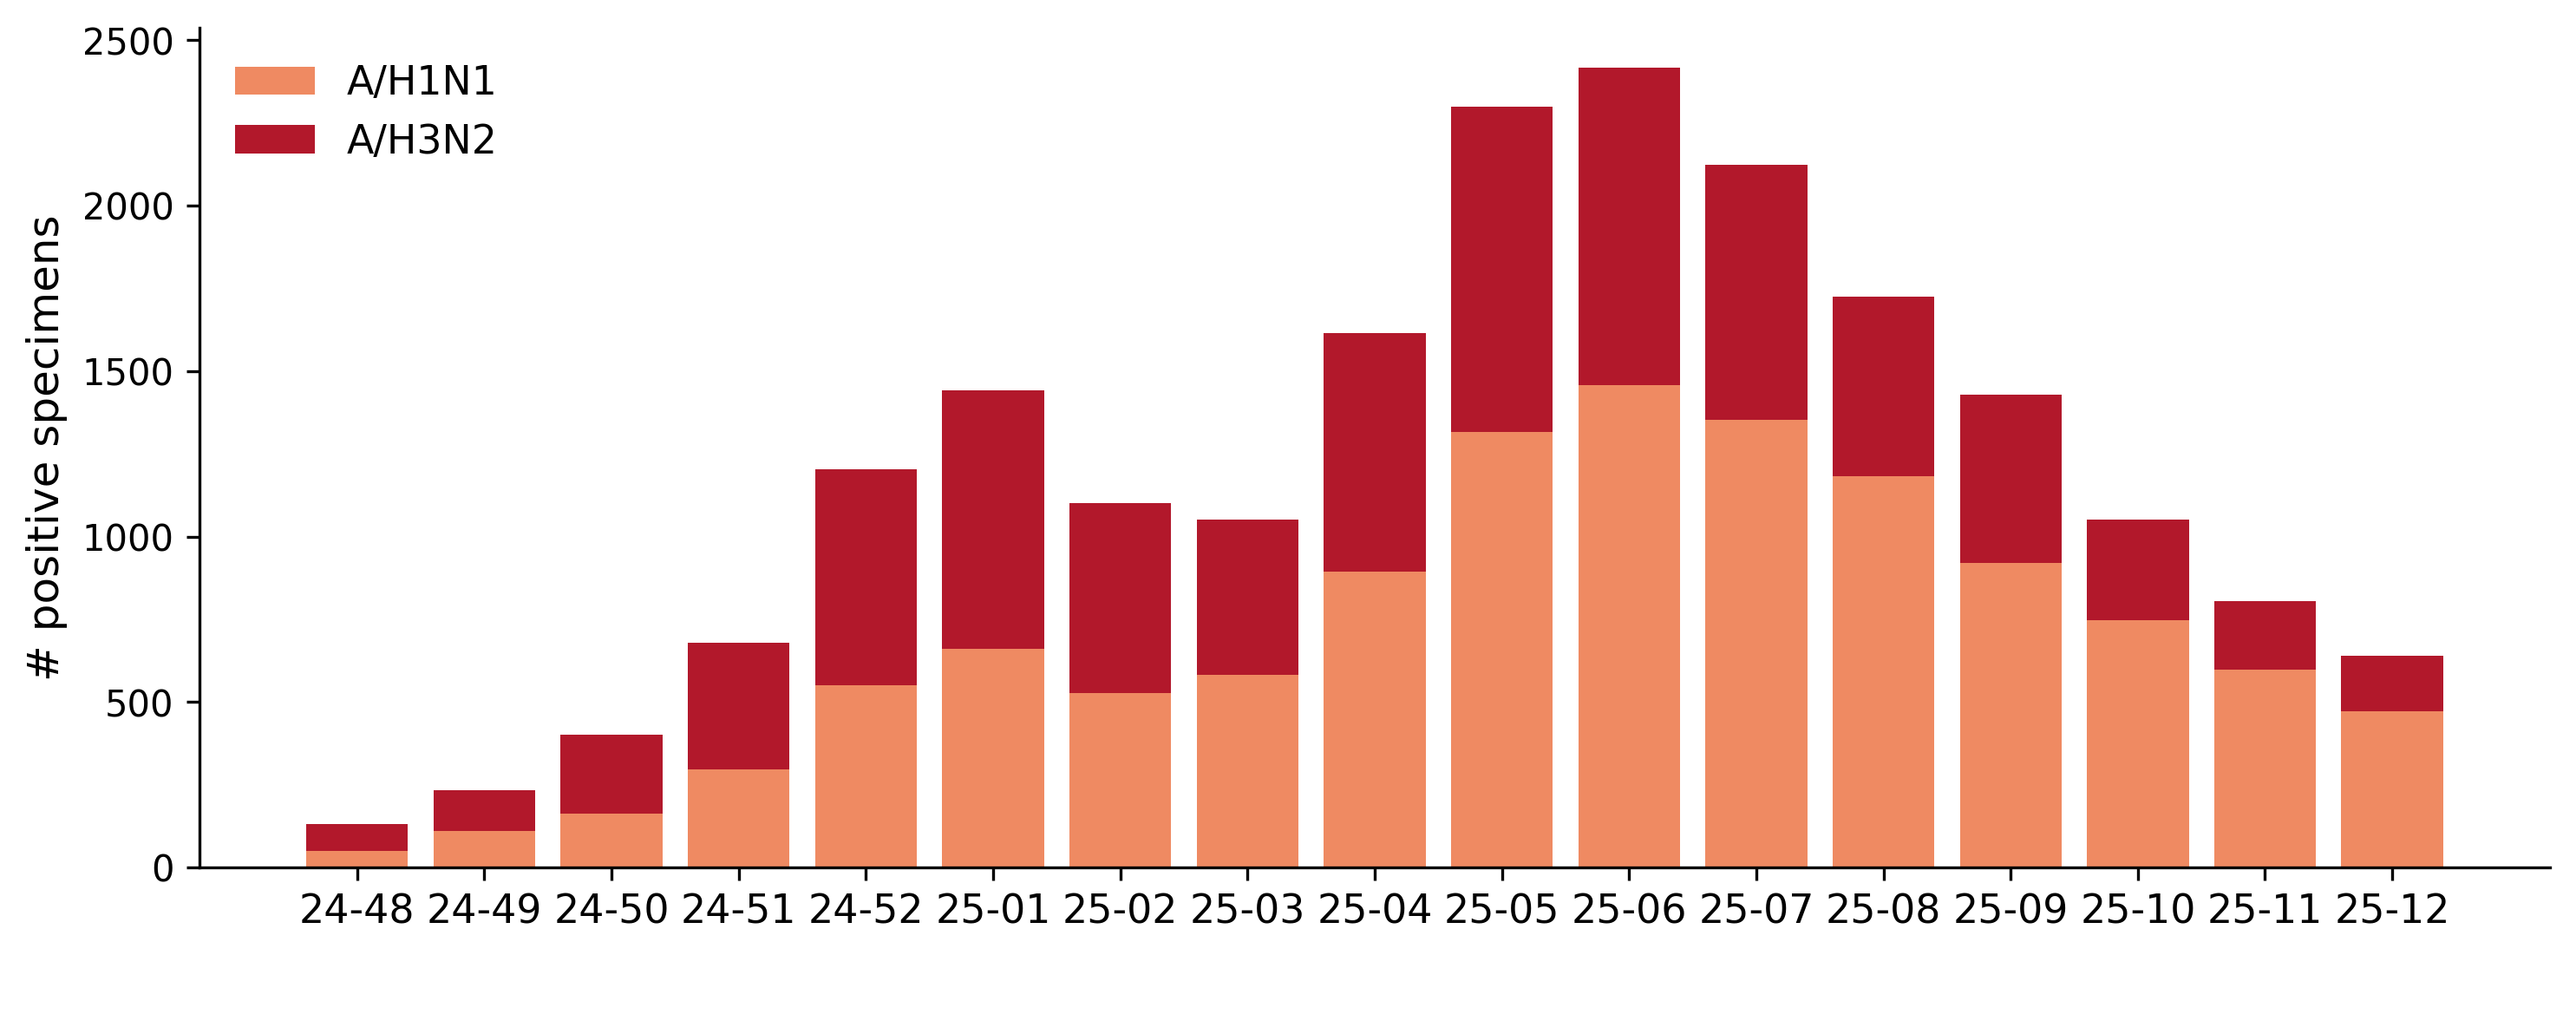

In [5]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

ah1n1_rate = df_subtype['A (H1N1)pdm09']
ah3n2_rate = df_subtype['A (H3)']
x = df_subtype['year_week_short']

ax.bar(x, ah1n1_rate, label='A/H1N1', color='#ef8a62', width=0.8)
ax.bar(x, ah3n2_rate, bottom=ah1n1_rate, label='A/H3N2', color='#b2182b', width=0.8)

ax.set_xlabel(' ', fontsize=12)
ax.set_ylabel('# positive specimens', fontsize=12)
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x,ha='center', fontsize=11)
ax.legend(loc = 'upper left', frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [6]:
df_subtype['dominant'] = df_subtype.apply(
    lambda row: 'A/H1N1' if row['A (H1N1)pdm09'] > row['A (H3)'] else 'A/H3N2', axis=1
)

df_subtype.to_csv('../output_data/influenza_subtypes/influenza_subtypes_age65plus.csv')

/var/folders/1k/099ld5px3839kqbm5hfxpgpc0000gp/T/ipykernel_18905/4126633114.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(sub_weeks, ha='center', fontsize=8)


Saved to ../figures/influenza_subtypes_vs_posterior_age65plus.png


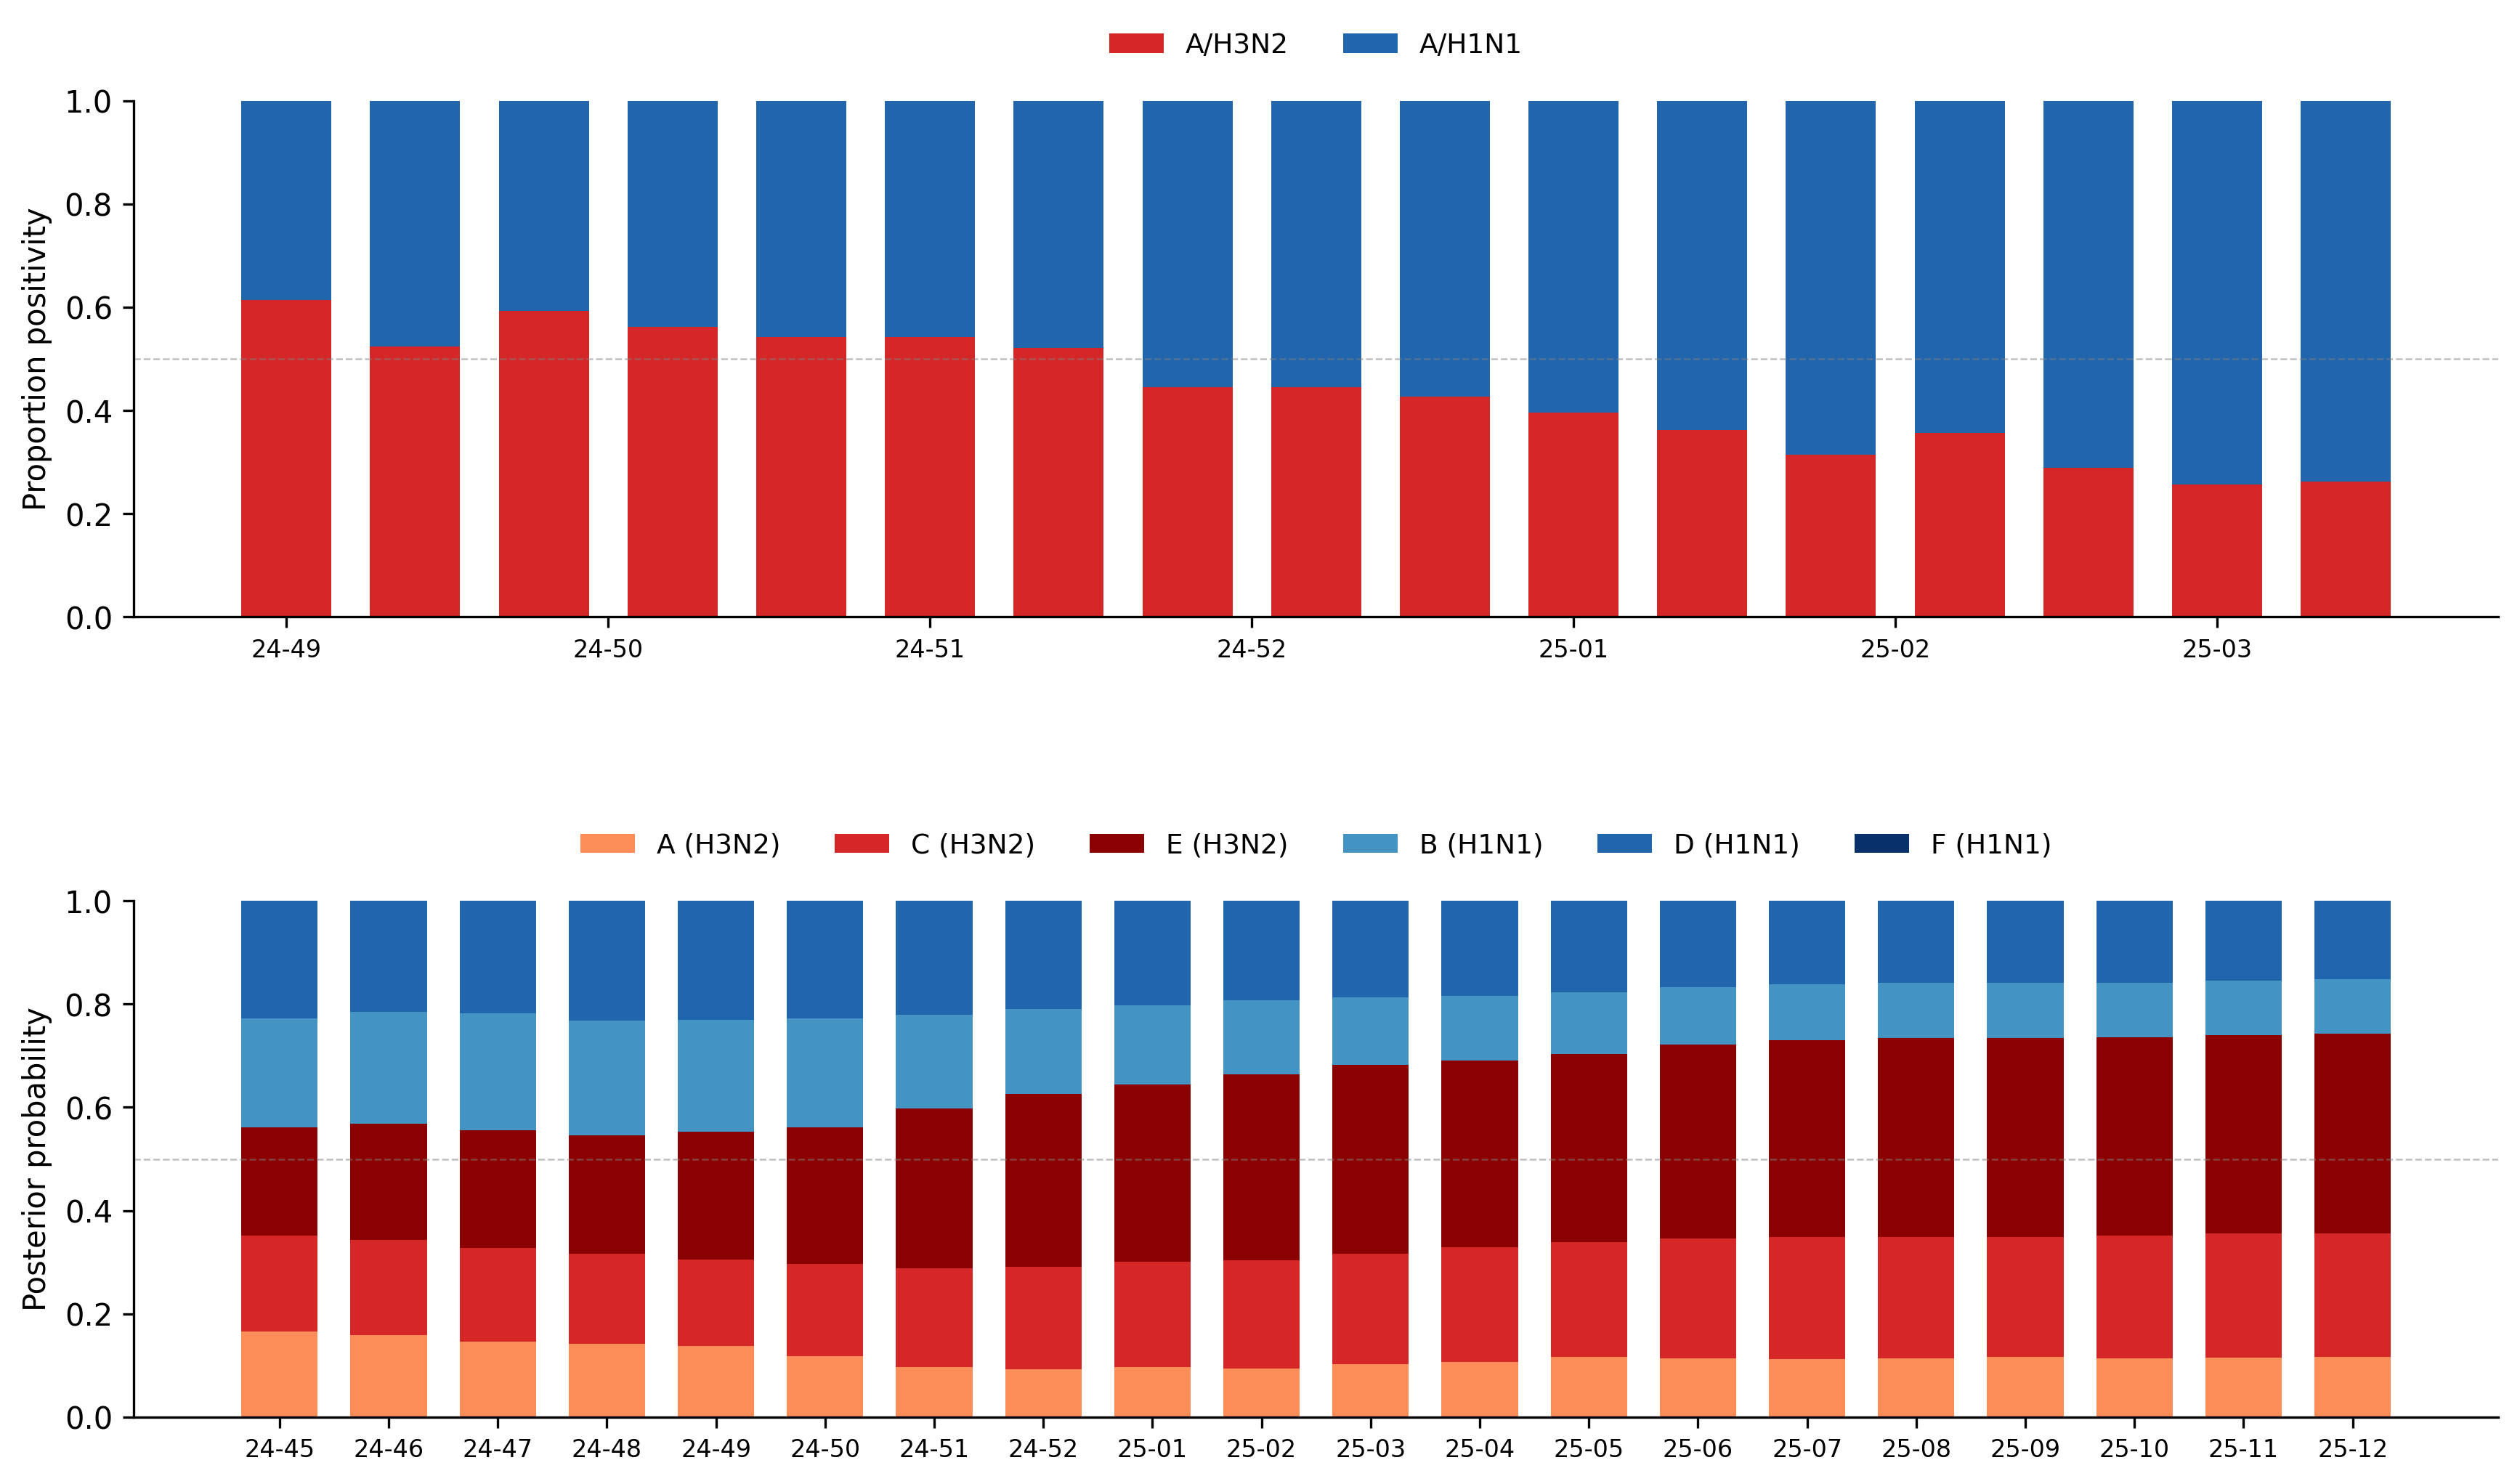

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── CONFIG ──────────────────────────────────────────────────
POSTERIOR_PATH = "../output_data/posterior_analysis_agestrata/posterior_distribution_65plus_wmape.csv"
SUBTYPES_PATH  = "../output_data/influenza_subtypes/influenza_subtypes_age65plus.csv"
K_VALUE        = 0.25   # which k to plot for the posterior
OUTPUT_PATH    = "../figures/influenza_subtypes_vs_posterior_age65plus.png"

# scenario grouping
H3N2_SCENARIOS  = ['A-2024-08-01', 'C-2024-08-01', 'E-2024-08-01']
H1N1_SCENARIOS  = ['B-2024-08-01', 'D-2024-08-01', 'F-2024-08-01']
SCENARIO_COLORS = {
    'A-2024-08-01': '#FC8D59',  # H3N2 - rosso chiaro
    'C-2024-08-01': '#D62728',  # H3N2 - rosso medio
    'E-2024-08-01': '#8B0000',  # H3N2 - rosso scuro
    'B-2024-08-01': '#4393C3',  # H1N1 - blu chiaro
    'D-2024-08-01': '#2166AC',  # H1N1 - blu medio
    'F-2024-08-01': '#08306B',  # H1N1 - blu scuro
}
SCENARIO_LABELS = {
    'A-2024-08-01': 'A (H3N2)',
    'C-2024-08-01': 'C (H3N2)',
    'E-2024-08-01': 'E (H3N2)',
    'B-2024-08-01': 'B (H1N1)',
    'D-2024-08-01': 'D (H1N1)',
    'F-2024-08-01': 'F (H1N1)',
}

# ── LOAD DATA ────────────────────────────────────────────────
df_post = pd.read_csv(POSTERIOR_PATH)
df_post = df_post[df_post.week <= '2025-03-22']
df_post['week'] = pd.to_datetime(df_post['week'])
iso = df_post['week'].dt.isocalendar()
df_post['date_week'] = iso['year'].astype(str).str[-2:] + '-' + iso['week'].astype(str).str.zfill(2)

df_sub  = pd.read_csv(SUBTYPES_PATH)

# posterior: filter k, pivot
df_post = df_post[df_post['k'] == K_VALUE].copy()
piv = df_post.pivot(index='date_week', columns='scenario', values='posterior_value').reset_index()
piv = piv.sort_values('date_week').reset_index(drop=True)
post_weeks = piv['date_week'].tolist()

# subtypes: compute proportions
df_sub['total']     = df_sub['A (H3)'] + df_sub['A (H1N1)pdm09']
df_sub['h3_prop']   = df_sub['A (H3)']            / df_sub['total']
df_sub['h1n1_prop'] = df_sub['A (H1N1)pdm09']     / df_sub['total']
sub_weeks = df_sub['year_week_short'].tolist()

# ── PLOT ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8), dpi=300)
gs  = gridspec.GridSpec(2, 1, hspace=0.55, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel 1: subtypes ────────────────────────────────────────
x1 = np.arange(len(sub_weeks))
ax1.bar(x1, df_sub['h3_prop'],   color='#D62728', label='A/H3N2', width=0.7)
ax1.bar(x1, df_sub['h1n1_prop'], color='#2166AC', label='A/H1N1',
        bottom=df_sub['h3_prop'], width=0.7)
ax1.set_xticklabels(sub_weeks, ha='center', fontsize=8)
ax1.set_ylabel('Proportion positivity', fontsize=10)
ax1.set_ylim(0, 1)
#ax1.set_title('2024–2025 season — influenza subtype positivity', fontsize=11, loc='left')
# legend: H3N2 group | H1N1 group
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, frameon=False, fontsize=9, ncol=6,
           loc='upper center', bbox_to_anchor=(0.5, 1.18))
ax1.spines[['top', 'right']].set_visible(False)
ax1.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# ── Panel 2: posterior weights ────────────────────────────────
x2      = np.arange(len(post_weeks))
bottom  = np.zeros(len(post_weeks))
scenario_order = H3N2_SCENARIOS + H1N1_SCENARIOS

for sc in scenario_order:
    vals = piv[sc].values
    ax2.bar(x2, vals, bottom=bottom,
            color=SCENARIO_COLORS[sc],
            label=SCENARIO_LABELS[sc],
            width=0.7)
    bottom += vals

# x labels: shorten to YY-MM-DD
ax2.set_xticks(x2)
ax2.set_xticklabels(post_weeks, ha='center', fontsize=8)
ax2.set_ylabel('Posterior probability', fontsize=10)
ax2.set_ylim(0, 1)
#ax2.set_title(f'2023–2024 season — scenario posterior weights (k={K_VALUE})', fontsize=11, loc='left')
ax2.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# legend: H3N2 group | H1N1 group
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, frameon=False, fontsize=9, ncol=6,
           loc='upper center', bbox_to_anchor=(0.5, 1.18))
ax2.spines[['top', 'right']].set_visible(False)

plt.savefig(OUTPUT_PATH, bbox_inches='tight', dpi=200)
print(f"Saved to {OUTPUT_PATH}")
plt.show()